# Chapter 3: Feature Importance for Predicting Sales

🧪 1. Load a Realistic Dataset (Seaborn “tips” as proxy for sales)

```bash
We’ll treat:

total_bill → sales
tip → upsell / extra revenue
size → number of customers
day, time → context

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


🔧 2. Simulate Missing Sales Data

In [2]:
df.loc[np.random.choice(df.index, 40, replace=False), 'total_bill'] = np.nan

print(df.isnull().sum())

total_bill    40
tip            0
sex            0
smoker         0
day            0
time           0
size           0
dtype: int64


📊 3. Encode Categorical Variables

In [3]:
# IterativeImputer needs numeric input:

df_encoded = df.copy()

df_encoded['sex'] = df_encoded['sex'].map({'Male':0, 'Female':1})
df_encoded['smoker'] = df_encoded['smoker'].map({'No':0, 'Yes':1})
df_encoded['day'] = df_encoded['day'].astype('category').cat.codes
df_encoded['time'] = df_encoded['time'].map({'Lunch':0, 'Dinner':1})

🔍 4. Visualize Missing Data

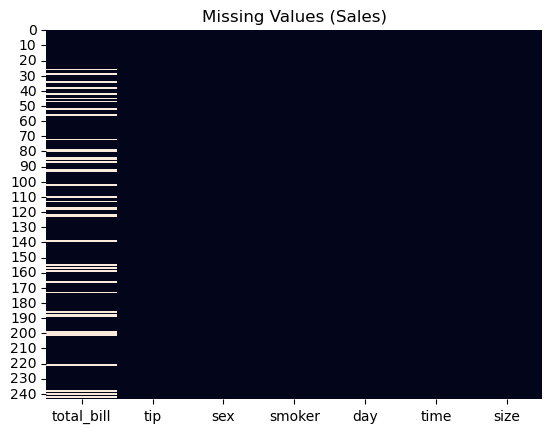

In [4]:
import matplotlib.pyplot as plt

sns.heatmap(df_encoded.isnull(), cbar=False)
plt.title("Missing Values (Sales)")
plt.show()

🧠 5. Apply Iterative Imputer

In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

iter_imp = IterativeImputer(random_state=42)

df_iter = df_encoded.copy()
df_iter[:] = iter_imp.fit_transform(df_encoded)

⚖️ 6. Compare with Mean Imputation

In [6]:
df_mean = df_encoded.copy()
df_mean['total_bill'] = df_mean['total_bill'].fillna(df_mean['total_bill'].mean())

📊 7. Compare Distributions

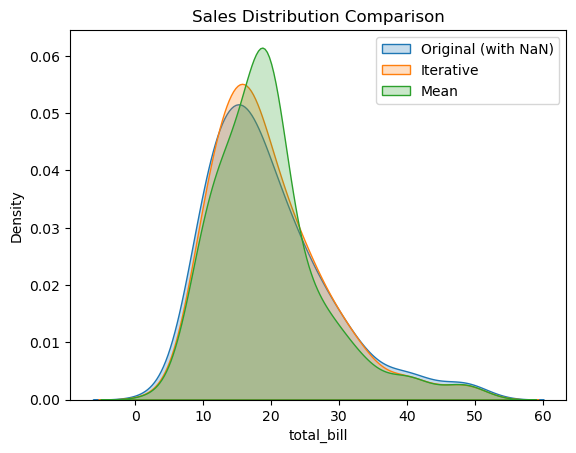

In [7]:
sns.kdeplot(df_encoded['total_bill'], label='Original (with NaN)', fill=True)
sns.kdeplot(df_iter['total_bill'], label='Iterative', fill=True)
sns.kdeplot(df_mean['total_bill'], label='Mean', fill=True)

plt.legend()
plt.title("Sales Distribution Comparison")
plt.show()

🧾 8. Compare Predictions

In [10]:
comparison = pd.DataFrame({
    'Original': df_encoded['total_bill'],
    'Iterative': df_iter['total_bill'],
    'Mean': df_mean['total_bill']
})
print(comparison.tail(15))


     Original  Iterative       Mean
229     22.12  22.120000  22.120000
230     24.01  24.010000  24.010000
231     15.69  15.690000  15.690000
232     11.61  11.610000  11.610000
233     10.77  10.770000  10.770000
234     15.53  15.530000  15.530000
235     10.07  10.070000  10.070000
236     12.60  12.600000  12.600000
237     32.83  32.830000  32.830000
238       NaN  24.893810  19.568971
239     29.03  29.030000  29.030000
240       NaN  15.095449  19.568971
241     22.67  22.670000  22.670000
242       NaN  13.835758  19.568971
243     18.78  18.780000  18.780000


```bash

🧠 What You’ll Notice
Mean Imputation ❌
Same value repeated
Destroys variability
Iterative Imputation ✅
Different values per row
Based on:
tip 💰
size 👥
time 🍽️
day 📅

🔥 9. Upgrade: Use Random Forest Imputer

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf_imp = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42),
    max_iter=10,
    random_state=42
)

df_rf = df_encoded.copy()
df_rf[:] = rf_imp.fit_transform(df_encoded)

📊 Compare Again

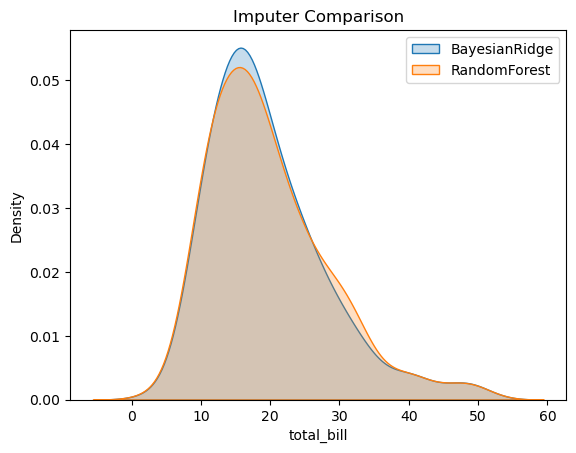

In [12]:
sns.kdeplot(df_iter['total_bill'], label='BayesianRidge', fill=True)
sns.kdeplot(df_rf['total_bill'], label='RandomForest', fill=True)

plt.legend()
plt.title("Imputer Comparison")
plt.show()

🧠 Business Interpretation

```bash

Now the model is doing:
sales = f(tip, size, day, time, smoker)

Example reasoning:

🍽️ Dinner + large group → higher bill
💰 High tip → likely high bill
📅 Weekend → higher spending
